<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/11_ImageProcessingRecitation_Fourier1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# 10. התמרת פורייה תרגול ראשון

ב3 התרוגלים הבאים נלמד על כלי חשוב FFT (Fast Fourier Transform)

מוטיבציה: FT מעביר מייצוג של האות במרחב הזמן לייצוג של האות במרחב התדר, ולכן תכונות שקשה לראות במרחב הזמן (מחזוריות, רעש מחזורי, חדות) נעשות לברורות יותר במרחב התדר וכן פעולות מסובכות במרחב הזמן (קונבולוציה) נעשות פשוטות במרחב התדר.
<dir>

In [9]:
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np
π = np.pi

In [10]:
def plot_axis(splot, x, xlabel, y, ylabel, xlim=False, ylim=False):
    splot.plot(x, y)
    if splot == plt:
        splot.xlabel(xlabel)
        splot.ylabel(ylabel)
        if xlim:
            plt.xlim(xlim)
        if ylim:
            plt.ylim(ylim)
    else:
        splot.set_xlabel(xlabel)
        splot.set_ylabel(ylabel)
        if xlim:
            splot.set_xlim(xlim)
        if ylim:
            splot.set_ylim(ylim)
    splot.axhline(y=0, color='k')
    splot.axvline(x=0, color='k')
    splot.grid()

<div dir="rtl">

## 10.1 2 סוגים של אותות:

DC (Direct Current) = אות קבוע בזמן.

AC (Alternating Current)) = אות שמשתנה בזמן.

<dir>

<div dir="rtl">

## 10.2 גל סינוס:

הנחת הבסיס: כל אות ניתן לפרק לסופרפוזיציה של גלי סינוס.

**ישנם 2 סוגים של יחידות עבור הפונקציה:**
* זמן $(t)$
* תדירות $(f)$


<dir>

<div dir="rtl">

###10.2.1 זמן $(t)$:

היחידות $(t)$ בפונקציה $S(t)=sin(2\pi ft)$ נמדדות במחזורים.

<dir>

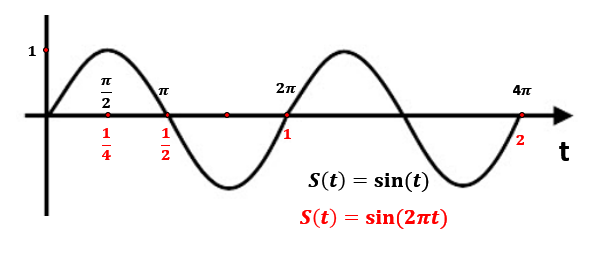

<div dir="rtl">

**שאלה:** מה הערך הממוצע של גל הסינוס?
<dir>

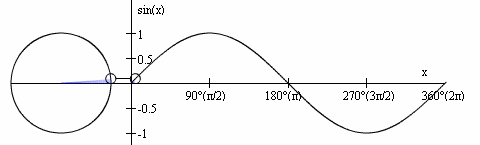

<div dir="rtl">

**תשובה:** הערך הממוצע של מחזור אחד הוא 0.
<dir>

<div dir="rtl">

**מחזור שלם = $2\pi=360^o$**
<dir>

<div dir="rtl">

**שאלה:** מה יקרה אם נחשב ממוצע על פני הזמן על סופרפוזיציה של גלי סינוס?
<dir>

<div dir="rtl">

###10.2.2 תדירות $(f)$:

$(f)$ בפונקציה $S(t)=sin(2\pi ft)$ מגדיר את מספר המחזורים שהגל משלים ביחידת זמן אחת.

<dir>

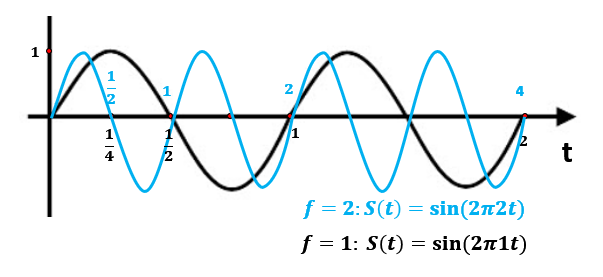

<div dir="rtl">

גל סינוס עם תדר מרחבי נמוך ← מתאר מבנה גס / איטי ← אזורים אחידים, תאורה כללית.

גל סינוס עם תדר מרחבי גבוה ← מתאר פרטים חדים / מהירים ← קצוות, טקסטורות, פרטים קטנים.

<dir>

<div dir="rtl">

###10.2.3 $(A)$ אמפליטודה:
$S(t)=A\times sin(2\pi ft)$

האמפליטודה קובעת את עוצמת הגל.

<dir>

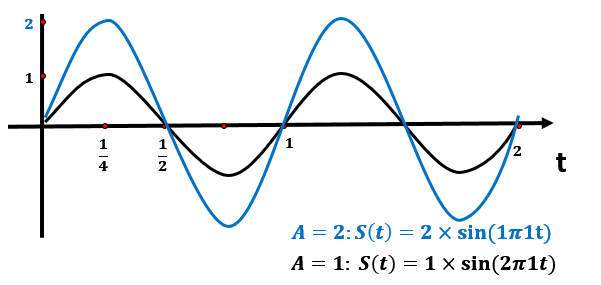

<div dir="rtl">

גל סינוס עם תדר מרחבי גבוה ← קצוות, טקסטורות, פרטים קטנים ← עם אמפליטודה נמוכה ← קצוות חלשים ומטושטשים.

גל סינוס עם תדר מרחבי גבוה ← קצוות, טקסטורות, פרטים קטנים ← עם אמפליטודה גבוהה ← קצוות חזקים.

<dir>

<div dir="rtl">

###10.2.4 פאזה $(\phi)$:
$S(t)=A\times sin(2\pi ft+\phi)$

הפאזה קובעת את נקודת ההתחלה של הגל בזמן ביחס לציר X.

* תוספת חיובית של פאזה (+) הגל זז שמאלה.
* תוספת שלילית של פאזה (-) הגל זז ימינה.

כלומר, הפאזה משפיעה על מיקום הגל בציר הזמן אך אינה משנה את התדר או האמפליטודה.

<dir>

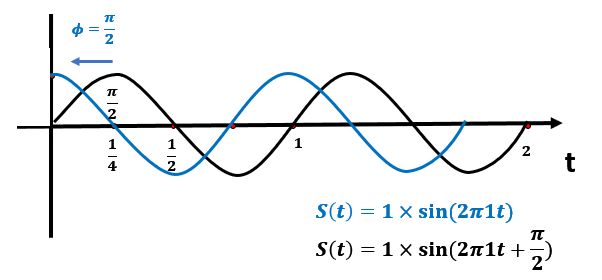

<div dir="rtl">

**החשמל בישראל: גל AC עם תדירות $f=50[Hz]$ ועם אמפליטודה נומינלית $A=230[V]$**
<dir>

<div dir="rtl">

##10.3 הדגמת גל סינוס:


<dir>

In [11]:
sampling_frequency = 1000
sampling_interval = 1 / sampling_frequency
begin_time = 0
end_time = 100
x = np.arange(begin_time, end_time, sampling_interval)

In [17]:
def sin_func(A,F,Φ):
    y = A * np.sin(2 * π * x * F + π*Φ)
    pos_ylim = np.max([np.ceil(np.max(np.abs(y)))+1, 1])
    ylim = [-pos_ylim, +pos_ylim]
    plot_axis(plt, x, 'Time', y, 'A', xlim=[0, 3], ylim=ylim)
    plt.show()

interactive(sin_func,A=(0,4.0, 0.25),F=(-2.0,4.0, 0.5), Φ=(-4.0,4.0, 0.5))

interactive(children=(FloatSlider(value=2.0, description='A', max=4.0, step=0.25), FloatSlider(value=1.0, desc…

<div dir="rtl">

## 10.4 התמרת פורייה FT:

התמרת פורייה מעבירה מהבסיס הסטנדרטי לבסיס התדרים.

**מה הוא הבסיס הסטנדרטי?**

האות מיוצג ע״י הערכים שלו בזמן: \begin{bmatrix}s_0 & s_1 & s_2 & \cdots\end{bmatrix}

כלומר כל נקודה בזמן היא קואורדינטה וזה ייצוג מרחבי/זמני. והאות מתקבל ע"י סופרפוזציה של כל התדרים ולכן נראה אות רציף ומשתנה.

**מה הוא בסיס התדרים?**

האות מייצוג ע"י ערכי התדרים שהוא מכיל: \begin{bmatrix}F_0 & F_1 & F_2 & \cdots\end{bmatrix}
כלומר כל $F_k$ מתאר כמה גל סינוס בתדר k יש באות. והאות מייוצג ע"י עמודות שונות ונפרדות לכל תדר.

**שימו לב:** FT לא משנה את האות, אלא משנה את איך שאנחנו מתאירם אותו.


<dir>

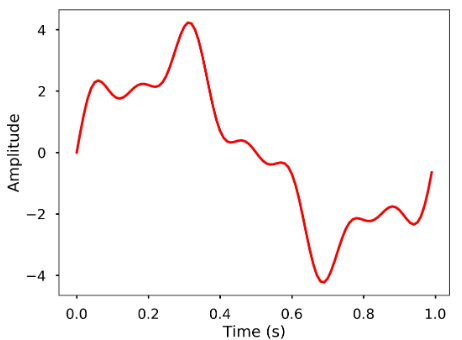

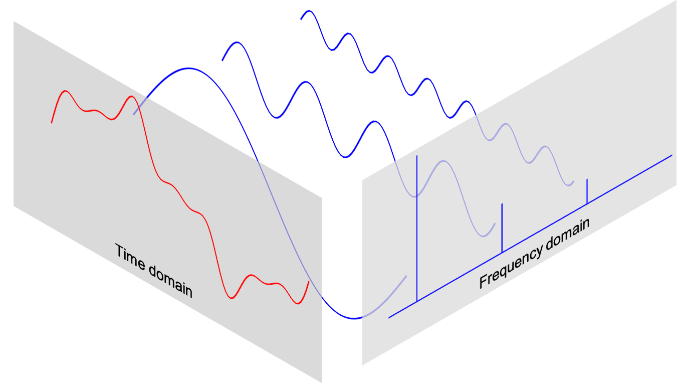

<div dir="rtl">

### 10.4.1 חזרה על אלגברה לינארית:

באלגברה לינארית כל וקטור:

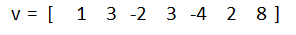

ניתן לייצוג ע"י צירוף לינארי בבסיס סטנדרטי:

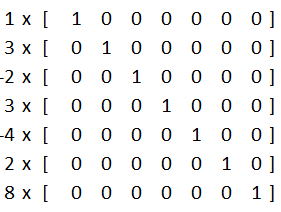

<dir>

<div dir="rtl">

### 10.4.2 צירוף לינארי באמצעות גלי סינוס:

**הבסיס הסטנדרטי אינו הכרחי ולכן ניתן להשתמש בכל בסיס שמכיל וקטורים בלתי תלויים ליניארית.**

דגימה בזמן של אות רציף היא וקטור עם $n$ נקודות: $[s_0,s_1,\dots,s_{n-1}]$

פורייה: דגימה של כל אות שרירותי (פונקציה) ניתנת לייצוג כצירוף לינארי של גלי סינוס עם תדרים שהם ערכים שלמים.

$S(t) = \sum_{k=1}^{N}A_{k}sin(2pif_{k}t+phi_{k})$

**בעיה:** הממוצע של גל סינוס הוא אפס, ולכן כל צירוף לינארי של גלי סינוס בלבד יהיה גם בעל ממוצע אפס.

**פתרון:**  כדי לייצג גם את הערך הממוצע של האות, מוסיפים רכיב קבוע (רכיב DC), שהוא רכיב בתדר אפס.
ולכן כאשר נציב $F_k=0$ נקבל:

 $S=Asin(2\pi\times 0x+\phi)=Asin(\phi)=const$

כלומר מתקבל ערך קבוע שאינו תלוי בזמן.

רכיב זה מסומן כ$F_0$ (תדר אפס), והוא מיוצג כוקטור קבוע מנורמל באורך
𝑛:

$F_0=(\frac{1}{\sqrt{n}},\frac{1}{\sqrt{n}},\dots,\frac{1}{\sqrt{n}})$

$F_1$ - זה תדר הבסיס שמשלים מחזור אחד לאורך $n$ הדגימות. הוא מייוצג ע"י:

$F_1: sin \frac{2\pi x}{n}=[0,sin \frac{2\pi\cdot 1}{n},sin \frac{2\pi\cdot 2}{n},\dots,sin \frac{2\pi\cdot (n-1)}{n}]$

$F_2$ - 2 מחזורים לאורך כל הדגימות.

$F_2: sin \frac{2\pi 2x}{n}$

$F_3$ - 3 מחזורים לאורך כל הדגימות.

$F_3: sin \frac{2\pi 3x}{n}$

$\dots$

$F_{n-1}$ – $sin \frac{2\pi \cdot (n-1)x}{n}$


כך נקבל וקטורים בלתי תלויים ליניאריים, מהם נוכל לשחזר את הווקטור המקורי.

$a_0F_0+a_1F_1+a_2F_2+\dots+a_nF_n$.  

כאשר המקדם $a_n$ הוא האמפליטודה של כל תדר $F_k$.


הערה: כדי לא לאבד את האות, תדר הדגימה צריך להיות לפחות פי שניים מתדר האות המקורי - משפט נייקוייסט.

לאחר ביצוע FT ציר הX כבר לא מייצג את הזמן $(t)$ אלא את התדר $(f)$.



<div dir="rtl">

### 10.4.3 הדגמה של FT:

In [13]:
def sin_func(A=1,F=1,Φ=0):
    y1 = A * np.sin(2*π*x*F + π*Φ)
    y2 = A * np.sin((2*π*x*F + π*Φ) / 2 )
    y = y1 + y2
    pos_ylim = np.max([np.ceil(np.max(np.abs(y)))+1, 1])
    ylim = [-pos_ylim, +pos_ylim]
    plot_axis(plt, x, 'Time', y, 'A', xlim=[0, 3], ylim=ylim)
    plt.show()

interactive(sin_func,A=(0.25,4.0, 0.25),F=(0,4.0, 0.5), Φ=(-4.0,4.0, 0.5))

interactive(children=(FloatSlider(value=1.0, description='A', max=4.0, min=0.25, step=0.25), FloatSlider(value…

In [14]:
def fft_plot(A1=1, F1=1, Φ1=0, A2=1, F2=2, Φ2=0):
    y1 = A1*np.sin(2*π*x*F1 + Φ1*π)
    y2 = A2*np.sin(2*π*x*F2 + Φ2*π)
    y = y1 + y2

    pos_ylim = np.max([np.ceil(np.max(np.abs(y)))+1, 1])
    ylim = [-pos_ylim, +pos_ylim]

    figure, axis = plt.subplots(4, 1, figsize=(12, 8))
    plt.subplots_adjust(hspace=0.4)
    plot_axis(axis[0], x, 'Time', y1, 'A', [0, 3], ylim)
    plot_axis(axis[1], x, 'Time', y2, 'A', [0, 3], ylim)
    plot_axis(axis[2], x, 'Time', y, 'A', [0, 3], ylim)
    fourier_transform = np.fft.fft(y)/len(y)           # Normalize amplitude
    fourier_transform = fourier_transform[range(int(len(y)/2))] # Exclude sampling frequency
    tp_count = len(y)
    values = np.arange(tp_count // 2)
    time_period = tp_count/sampling_frequency
    frequencies = values/time_period
    plot_axis(axis[3], frequencies, 'Frequency', 2*abs(fourier_transform), 'A', [-1, 5], [0, 1])
    plt.show()

interactive(fft_plot, A1=(0.25,4.0, 0.25), Φ1=(-4.0,4.0, 0.5), F1=(0,4.0, 0.5),A2=(0.25,4.0, 0.25), F2=(0,4.0, 0.5),Φ2=(-4.0,4.0, 0.5))

interactive(children=(FloatSlider(value=1.0, description='A1', max=4.0, min=0.25, step=0.25), FloatSlider(valu…

<div dir="rtl">

### 10.4.4 הוספת רעש:

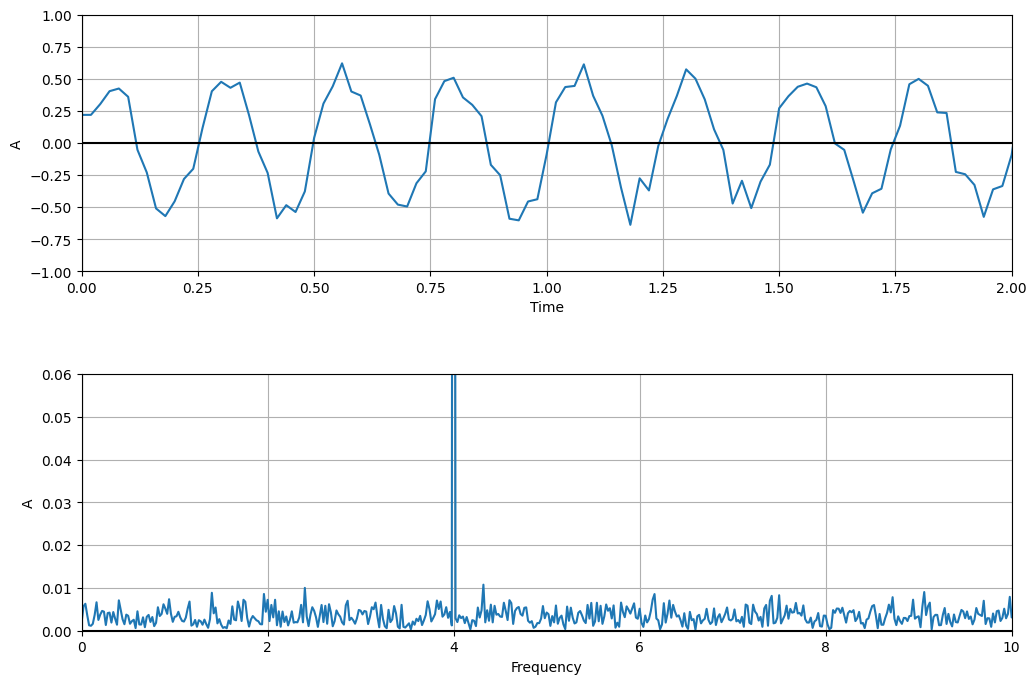

In [15]:
A=0.5; F=4; noise_level = 0.1
ylim = [-1, +1]
sampling_frequency = 50
sampling_interval = 1 / sampling_frequency
begin_time = 0
end_time = 50
x = np.arange(begin_time, end_time, sampling_interval)
noise = np.random.normal(scale=noise_level, size=x.size)
y = A*np.sin(2*π*x*F) + noise
pos_ylim = np.max([np.ceil(np.max(np.abs(y)))+1, 1])
figure, axis = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)
plot_axis(splot=axis[0], x=x, xlabel='Time', y=y, ylabel='A', xlim=[0, 2], ylim=ylim)
fourier_transform = np.fft.fft(y)/len(y)           # Normalize amplitude
fourier_transform = fourier_transform[range(int(len(y)/2))] # Exclude sampling frequency
tp_count = len(y)
values = np.arange(tp_count // 2)
time_period = tp_count/sampling_frequency
frequencies = values/time_period
plot_axis(splot=axis[1], x=frequencies, xlabel='Frequency', y=2*abs(fourier_transform), ylabel='A',xlim=[0,10], ylim=[0,0.06])
plt.show()